## Devoir : apprentissage par renforcement dans Grid World

### Instructions :
1. Initialiser le Grid World avec une largeur, une hauteur et des positions bloquées données.
2. Implémenter un agent Q-Learning et un agent SARSA pour naviguer dans le Grid World.
3. Entraîner l'agent à atteindre la position objectif depuis la position de départ tout en évitant les positions bloquées.
4. Visualiser la progression de l'agent en affichant la grille à chaque étape.
5. Adapter le code à Grid World v2, qui contient des murs, des marais et des falaises.
    - Un mur bloque le déplacement de l'agent.
    - Un marais donne une récompense négative à l'agent.
    - Une falaise transporte l'agent au point de départ.
6. Expérimenter avec différentes valeurs de alpha, gamma, différentes récompenses et d'autres paramètres afin d'observer leurs effets sur les agents dans 5 cartes différentes.
7. Analyser les performances des agents en mesurant le nombre d'étapes nécessaires pour atteindre l'objectif à chaque épisode, comparer l'agent Q-Learning et l'agent SARSA, puis expliquer le résultat.


Voici un exemple utilisant l'interface pygame pour simuler un agent aléatoire.

--- 

Dans un premier temps, il est important de définir le problème étudié. Nous considérons un environnement de type GridWorld, dans lequel un agent se déplace sur une grille à partir d’une position initiale (start) afin d’atteindre une position cible (goal). L’objectif de l’agent est de maximiser la récompense cumulée au cours de ses déplacements, tout en évitant les trajectoires sous-optimales.

Pour résoudre ce problème, nous utilisons deux algorithmes d’apprentissage par renforcement : Q-Learning et SARSA. Ces deux méthodes reposent sur l’apprentissage d’une fonction de valeur d’action, mais se distinguent par leur nature. Le Q-Learning est un algorithme off-policy, qui apprend la politique optimale indépendamment des actions réellement exécutées, tandis que SARSA est un algorithme on-policy, qui apprend en fonction de la politique effectivement suivie par l’agent.

Enfin, nous nous appuyons sur le framework grid_world afin de modéliser l’environnement, gérer les interactions entre l’agent et la grille, et implémenter les différentes stratégies d’apprentissage.

In [171]:
from grid_world import GridWorld, PygameGridWorld
import numpy as np
# check your taskbar for running pygame application GridWorld
game = PygameGridWorld()
grid_world = game.grid_world

#example of using GridWorld, we show the basic functions for 
# state , action, next_state, and reached_goal
state = grid_world.player_position
action = np.random.choice(grid_world.actions)
reached_goal = grid_world.move_player(action)
next_state = grid_world.player_position
print("state, action, next_state, reached_goal")
print(state, action, next_state, reached_goal)

game.main(auto_close=True) # auto_close will close screen automtatically at the end of game.


state, action, next_state, reached_goal
(0, 0) right (1, 0) False


### Agent Q-Learning

L’algorithme Q-Learning est une méthode d’apprentissage par renforcement sans modèle (*model-free*) qui permet à un agent d’apprendre à prendre des décisions à partir des récompenses qu’il reçoit. Il vise à estimer la fonction de valeur d’action $Q(s,a)$, qui mesure la qualité d’une action $a$ dans un état $s$.

Cet algorithme est dit *off-policy*, car il apprend une politique optimale indépendamment de la politique utilisée pour explorer l’environnement. Il repose sur une **Q-table**, qui associe à chaque paire état-action $(s,a)$ une valeur, mise à jour après chaque interaction selon :

$$
Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha \left( R_{t+1} + \gamma \max_a Q(s_{t+1},a) - Q(s_t,a_t) \right)
$$

où $s_t$ est l’état courant, $a_t$ l’action effectuée, $R_{t+1}$ la récompense, $s_{t+1}$ l’état suivant, $\alpha$ le taux d’apprentissage et $\gamma$ le facteur d’actualisation.

La fonction *choose_action* repose sur une stratégie $\varepsilon$-greedy : avec une probabilité $\varepsilon$, l’agent explore en choisissant une action aléatoire, sinon il exploite en sélectionnant l’action maximisant $Q(s,a)$.

La fonction *learn* met à jour la Q-table en corrigeant la valeur actuelle à partir d’une nouvelle estimation (récompense immédiate + meilleur futur possible), ce qui permet à l’agent d’améliorer progressivement ses décisions et de converger vers une politique optimale.

### *Fonction *choose_action**

La fonction *choose_action* permet de sélectionner l’action à effectuer à partir d’un état donné. Elle repose sur une stratégie **$\varepsilon$-greedy**, qui établit un compromis entre exploration et exploitation :

- avec une probabilité $\varepsilon$, l’agent choisit une action aléatoire afin d’explorer l’environnement ;
- avec une probabilité $1 - \varepsilon$, il choisit l’action maximisant la valeur $Q(s,a)$ :
$
a = \arg\max_a Q(s,a)
$

Ainsi, une valeur élevée de $\varepsilon$ favorise l’exploration, tandis qu’une valeur faible favorise l’exploitation des connaissances acquises.


### *Fonction *learn**

La fonction *learn* correspond à l’étape d’apprentissage. À partir de l’état courant $s_t$ et de l’action $a_t$, l’agent observe une transition vers un nouvel état $s_{t+1}$ ainsi qu’une récompense $R_{t+1}$.
Une nouvelle estimation, appelée **cible**, est alors calculée :

$
\text{cible} = R_{t+1} + \gamma \max_a Q(s_{t+1},a)
$

La valeur $Q(s_t,a_t)$ est ensuite mise à jour en corrigeant l’ancienne estimation :
$
Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha \left( \text{cible} - Q(s_t,a_t) \right)
$

Cette mise à jour permet d’ajuster progressivement la Q-table en fonction des nouvelles observations. Au fil des itérations, l’agent améliore ses estimations et converge vers une politique optimale.

In [172]:
import random
import numpy as np

class QLearningAgent:
    def __init__(self, grid_world, alpha=0.1, gamma=0.95, epsilon=0.1):
        self.grid_world = grid_world
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = {}
        self.actions = ["up", "down", "left", "right"]

    def get_q_value(self, state, action):
        return self.q_table.get((state, action), 0)

    def update_q_value(self, state, action, new_value):
        self.q_table[(state, action)] = new_value

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.choice(self.actions)  # your implementation
        else:
            q_values = [self.get_q_value(state, action) for action in self.actions]
            max_q_value = q_values.index(max(q_values)) # on prend la valeur la plus elevé de la qtable pour l'instant s
            return self.actions[max_q_value]

    def learn(self, state, action, reward, next_state):
        current_q_value = self.get_q_value(state, action)
        next_q_values = [self.get_q_value(next_state, next_action) for next_action in self.actions]
        max_next_q_value = max(next_q_values)
        new_q_value = current_q_value + self.alpha * (reward + self.gamma * max_next_q_value - current_q_value) 
        self.update_q_value(state, action, new_q_value)


### Agent SARSA

L’algorithme SARSA est une méthode d’apprentissage par renforcement sans modèle (*model-free*) qui permet à un agent d’apprendre une politique à partir des actions qu’il effectue réellement. Contrairement au Q-Learning, il s’agit d’un algorithme *on-policy*, ce qui signifie qu’il apprend la valeur d’une politique en suivant exactement cette politique.

Le principe repose sur l’utilisation d’une **Q-table**, qui associe à chaque paire état-action $(s,a)$ une valeur. La mise à jour prend en compte l’action réellement choisie dans l’état suivant, selon la règle :

$$
Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left( R_{t+1} + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) \right)
$$

où $s_t$ est l’état courant, $a_t$ l’action effectuée, $R_{t+1}$ la récompense obtenue, $s_{t+1}$ l’état suivant, $a_{t+1}$ l’action réellement choisie dans cet état, $\alpha$ le taux d’apprentissage et $\gamma$ le facteur d’actualisation.

La fonction *choose_action* repose sur une stratégie $\varepsilon$-greedy : avec une probabilité $\varepsilon$, l’agent choisit une action aléatoire (exploration), sinon il sélectionne l’action maximisant $Q(s,a)$ (exploitation).

La fonction *learn* met à jour la Q-table en utilisant l’action réellement choisie $a_{t+1}$ dans l’état suivant, ce qui permet à l’agent d’apprendre en tenant compte de son comportement effectif. Cette particularité rend SARSA plus prudent, notamment dans des environnements comportant des risques, car il intègre directement les conséquences de l’exploration dans son apprentissage.

In [173]:
# Create a SARSA agent class
class SarsaAgent:
    def __init__(self, grid_world, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.grid_world = grid_world
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = {}
        self.actions = ["up", "down", "left", "right"]

    def get_q_value(self, state, action):
        return self.q_table.get((state, action), 0)

    def update_q_value(self, state, action, new_value):
        self.q_table[(state, action)] = new_value

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.choice(self.actions)  # your implementation
        else:
            q_values = [self.get_q_value(state, action) for action in self.actions]
            max_q_value = q_values.index(max(q_values))  # your implementation
            return self.actions[max_q_value]

    def learn(self, state, action, reward, next_state, next_action):
        current_q_value = self.get_q_value(state, action)
        next_q_value = self.get_q_value(next_state, next_action)
        new_q_value = current_q_value + self.alpha * (reward + self.gamma * next_q_value - current_q_value)
        self.update_q_value(state, action, new_q_value)


### Différence théorique entre Q-Learning et SARSA

La différence fondamentale entre Q-Learning et SARSA repose sur leur nature *off-policy* et *on-policy*, ce qui influence directement leur manière de gérer le compromis entre **exploration** et **exploitation**.

Le **Q-Learning** est un algorithme *off-policy*. Cela signifie qu’il apprend la politique optimale indépendamment des actions réellement exécutées. Lors de la mise à jour, il suppose que l’agent choisira toujours la meilleure action possible dans l’état suivant, même si ce n’est pas le cas en pratique. Formellement, il utilise le terme $\max_a Q(s_{t+1},a)$, ce qui correspond à un comportement **optimiste**. Ainsi, l’exploration (via $\varepsilon$-greedy) est utilisée pour collecter des données, mais n’est pas prise en compte dans l’apprentissage. L’algorithme tend donc à privilégier des stratégies potentiellement risquées mais optimales en théorie.

À l’inverse, **SARSA** est un algorithme *on-policy*. Il apprend la valeur de la politique réellement suivie par l’agent, y compris les actions issues de l’exploration. Lors de la mise à jour, il utilise l’action effectivement choisie $a_{t+1}$, ce qui signifie qu’il prend en compte les erreurs ou choix aléatoires liés à l’exploration. Par conséquent, SARSA adopte un comportement plus **prudent**, car il anticipe le fait que l’agent ne sera pas toujours optimal dans ses décisions.

Ainsi, la différence principale peut se résumer comme suit :
- Q-Learning apprend une politique optimale théorique en supposant une exploitation parfaite du futur ;
- SARSA apprend une politique réaliste en intégrant explicitement le compromis exploration/exploitation.

En pratique, cela se traduit souvent par des comportements différents : Q-Learning converge plus rapidement vers une solution optimale, tandis que SARSA produit des trajectoires plus sûres dans des environnements incertains ou risqués.

### Dilemme central : exploration vs exploitation

Contrairement à l’apprentissage supervisé, les données en apprentissage par renforcement ne sont pas fixes : elles dépendent directement du comportement de l’agent. Ainsi, l’agent doit en permanence arbitrer entre deux objectifs opposés :

- **Exploration** : découvrir de nouvelles actions afin d’améliorer sa connaissance de l’environnement et potentiellement trouver de meilleures stratégies.
- **Exploitation** : utiliser les connaissances actuelles pour maximiser immédiatement les récompenses.

L’exploration consiste à tester des actions peu connues, qui pourraient mener à des états plus favorables, tandis que l’exploitation privilégie les actions ayant déjà donné de bons résultats.

Ce compromis constitue un défi majeur : l’agent doit explorer suffisamment pour ne pas manquer des états à forte récompense, tout en évitant de perdre du temps dans des états peu intéressants. Une exploration efficace est ainsi considérée comme un signe d’intelligence, car elle permet d’améliorer progressivement les performances globales.

En pratique :
- l’**exploitation** favorise les actions menant à des états déjà identifiés comme bénéfiques ;
- l’**exploration** consiste à tenter des actions incertaines pouvant révéler de meilleures opportunités.

### Expériences
L'expérience porte sur la comparaison de deux types d'agents : Q-Learning et SARSA. Nous comparons le nombre total d'étapes et les récompenses cumulées par époque pendant l'exécution afin d'observer leurs comportements différents.


### **Implémentation et simplifications**

Dans cette implémentation, certaines simplifications ont été introduites afin de se concentrer sur le fonctionnement des algorithmes plutôt que sur la complexité de l’environnement. Par exemple, bien qu’une fonction de récompense plus riche soit définie (avec marais et falaises), on utilise ici une version simplifiée :

- $r = +100$ si l’objectif est atteint  
- $r = -1$ sinon  
On peut se permettre cette simplification car l’objectif principal est d’analyser le comportement des algorithmes Q-Learning et SARSA, et non d’optimiser finement la modélisation de l’environnement.


**Entraînement Q-Learning** :
L’entraînement de l’agent Q-Learning suit une boucle classique et directe :
1. Observer l’état courant $s$
2. Choisir une action $a$ via une stratégie $\varepsilon$-greedy
3. Exécuter l’action et observer le nouvel état $s'$
4. Recevoir la récompense $r$
5. Mettre à jour la Q-table :
$
Q(s,a) \leftarrow Q(s,a) + \alpha \left( r + \gamma \max_a Q(s',a) - Q(s,a) \right)
$
6. Répéter jusqu’à atteindre l’état terminal

Cette version est volontairement basique : elle ne prend pas en compte de limites de pas (*max steps*) ni de récompenses complexes.

**Entraînement SARSA** :
L’entraînement de SARSA suit une logique très proche, avec une différence clé liée à son caractère *on-policy* :

1. Initialiser l’état $s$ et choisir une action $a$
2. Exécuter l’action → obtenir $s'$ et $r$
3. Choisir une nouvelle action $a'$ dans $s'$
4. Mettre à jour :
$
Q(s,a) \leftarrow Q(s,a) + \alpha \left( r + \gamma Q(s',a') - Q(s,a) \right)
$

5. Remplacer $s \leftarrow s'$ et $a \leftarrow a'$
6. Répéter jusqu’à l’état terminal

**Remarque** : Les deux implémentations restent volontairement simples. Elles suivent le schéma standard des algorithmes de reinforcement learning, sans ajout de mécanismes avancés (limite de pas, reward shaping, etc.). Cela permet de mieux mettre en évidence la différence fondamentale entre Q-Learning (*off-policy*) et SARSA (*on-policy*). 


On pourrait rajouter également des rewards pour les falaises ou marais par exemple.

In [190]:
def get_intended_position(state, action, grid_world):# on prend l'origine en haut a gauche p
    x, y = state
    if action == "up":
        y = max(0, y - 1)
    elif action == "down":
        y = min(grid_world.height - 1, y + 1)
    elif action == "left":
        x = max(0, x - 1)
    elif action == "right":
        x = min(grid_world.width - 1, x + 1)
    return (x, y)


def get_reward(grid_world, reached_goal, intended_position, reward_goal=100, reward_default=-1,
               reward_marsh=-10, reward_cliff=-100):
    if reached_goal:
        return reward_goal
    if intended_position in getattr(grid_world, "cliff_positions", []):
        return reward_cliff
    if intended_position in getattr(grid_world, "marsh_positions", []):
        return reward_marsh
    return reward_default




def train_q_learning_agent(agent, grid_world, max_steps=200, rewards_config=None):
    rewards_config = rewards_config or {}
    steps = 0
    rewards = 0

    while not grid_world.is_game_over() and steps < max_steps:
        state = grid_world.player_position
        action = agent.choose_action(state)

        intended_position = get_intended_position(state, action, grid_world)
        reached_goal = grid_world.move_player(action)
        next_state = grid_world.player_position

        reward = get_reward(grid_world, reached_goal, intended_position, **rewards_config)

        agent.learn(state, action, reward, next_state)

        steps += 1
        rewards += reward

    return steps, rewards


def train_sarsa_agent(agent, grid_world, max_steps=200, rewards_config=None):
    rewards_config = rewards_config or {}
    steps = 0
    rewards = 0

    state = grid_world.player_position
    action = agent.choose_action(state)

    while not grid_world.is_game_over() and steps < max_steps:  #game over fonction de l'environement 
        intended_position = get_intended_position(state, action, grid_world)

        reached_goal = grid_world.move_player(action)
        next_state = grid_world.player_position

        reward = get_reward(grid_world, reached_goal, intended_position, **rewards_config)

        next_action = agent.choose_action(next_state)

        agent.learn(state, action, reward, next_state, next_action)

        state = next_state
        action = next_action

        steps += 1
        rewards += reward

    return steps, rewards

### Fonction ExperimentAgent

La fonction `ExperimentAgent` permet d’entraîner un agent (Q-Learning ou SARSA) sur plusieurs épisodes dans un environnement GridWorld.

À chaque épisode :
- on réinitialise l’état initial,
- on entraîne l’agent avec `train_q_learning_agent` ou `train_sarsa_agent`,
- on enregistre le nombre de pas et la récompense totale.

Le paramètre $\varepsilon$ diminue progressivement :
$
\varepsilon \leftarrow \max(0.1, \varepsilon - \text{decay})
$
ce qui réduit l’exploration au profit de l’exploitation.

La Q-table est sauvegardée régulièrement avec `pickle`.
La fonction retourne :
- `steps_per_episode` (efficacité),
- `reward_per_episode` (performance).

In [175]:
def ExperimentAgent(your_agent_class_object,
                    epsilon=0.9, epsilon_decay=0.15,
                    num_episodes=300, alpha=0.1, gamma=0.99,
                    grid_world=None, max_steps=110, rewards_config=None, auto_replay=False, ticks=50):
    if grid_world is None:
        grid_world = GridWorld(10, 10,
                        wall_positions=[ (1, 1), (2, 2), (3, 3), (4, 4),
                                            (3, 2), (3, 1),
                                            (5, 5), (5,0),
                                            (6, 1), (6,2), (6,3),
                                            (8, 9), (8, 8),  (8, 7),(8, 6),
                                            (8, 5), (8, 4),(8, 3),(8, 2),],
                        goal_positions=[(9,9)])
    YourAgentClass = your_agent_class_object
    agent = YourAgentClass(grid_world, alpha=alpha,
                            gamma=gamma, epsilon=epsilon
                            )

    steps_per_episode = []
    reward_per_episode = []
    for episode in range(num_episodes):
        grid_world.player_position = grid_world.init_player_position
        if agent.__class__.__name__ == "QLearningAgent":
            steps, rewards = train_q_learning_agent(agent, grid_world, max_steps, rewards_config)
        elif agent.__class__.__name__ == "SarsaAgent":
            steps, rewards = train_sarsa_agent(agent, grid_world, max_steps, rewards_config)
        else:
            raise ValueError(f"Agent non supporté : {agent.__class__.__name__}")

        steps_per_episode.append(steps)
        reward_per_episode.append(rewards)

        # enregistrer les politiques apprises dans des fichiers pickle
        if episode % 50 == 0:
            agent.epsilon = max(0.1, agent.epsilon - epsilon_decay)
            # Enregistrer la politique apprise
            with open(f"learned_policy_{YourAgentClass.__name__}_episode_{episode}.pkl", "wb") as f:
                pickle.dump(agent.q_table, f)

    # Sauvegarde aussi la politique finale pour faciliter l'analyse.
    with open(f"learned_policy_{YourAgentClass.__name__}_episode_{num_episodes}.pkl", "wb") as f:
        pickle.dump(agent.q_table, f)

    print(f"{YourAgentClass.__name__} entraîné pendant {num_episodes} épisodes")

    return steps_per_episode, reward_per_episode, agent


In [196]:
steps_per_episode_QLearning, reward_per_episode_QLearning, q_learning_agent = ExperimentAgent(QLearningAgent, num_episodes=1000 , max_steps=500)

steps_per_episode_Sarsa, reward_per_episode_Sarsa, sarsa_agent = ExperimentAgent(SarsaAgent, num_episodes=1000 , max_steps=500)

QLearningAgent entraîné pendant 1000 épisodes
SarsaAgent entraîné pendant 1000 épisodes


In [177]:
def plot_comparison(steps_per_episode_QLearning, reward_per_episode_QLearning,
                    steps_per_episode_Sarsa, reward_per_episode_Sarsa):

    # Plot the graph of steps per episode
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
    ax1.plot(steps_per_episode_QLearning, color='blue', alpha=0.7)
    ax1.plot(steps_per_episode_Sarsa, color='orange', alpha=0.7)
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Steps')
    ax1.legend(['QLearningAgent' ,'SarsaAgent'])
    ax1.set_title(f'Total Steps per Episode')
    ax1.set_yscale('log')

    # Plot the graph of steps per episode
    ax2.plot(reward_per_episode_QLearning, color='blue', alpha=0.7)
    ax2.plot(reward_per_episode_Sarsa, color='orange', alpha=0.7)
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Steps')
    ax2.legend(['QLearningAgent' ,'SarsaAgent'])
    ax2.set_title(f'Cumulative Rewards per Episode')
    ax2.set_yscale('log')
    plt.show()

Les résultats montrent que Q-Learning converge plus rapidement que SARSA, avec une diminution plus rapide du nombre d’étapes et une augmentation plus précoce des récompenses. Cela s’explique par son caractère off-policy : lors de la mise à jour, il utilise systématiquement la meilleure action possible via  
$
\max_a Q(s,a)
$
indépendamment de la politique réellement suivie. Cette approche optimiste accélère la propagation des valeurs élevées, mais introduit un biais d’optimisme, souvent appelé *overestimation bias*. Ce biais peut entraîner une variance plus élevée dans les estimations et rendre l’apprentissage moins stable, en particulier dans des environnements stochastiques ou comportant des pénalités importantes.

À l’inverse, SARSA adopte une approche on-policy. La mise à jour repose sur l’action réellement choisie :
$
Q(s,a) \leftarrow Q(s,a) + \alpha \big(r + \gamma Q(s',a') - Q(s,a)\big)
$
ce qui intègre directement l’exploration dans l’apprentissage. En tenant compte du comportement réel de l’agent, SARSA réduit le biais d’optimisme et présente généralement une variance plus faible. L’apprentissage est donc plus progressif, mais aussi plus stable et plus robuste face aux incertitudes.

D’un point de vue théorique, Q-Learning privilégie la rapidité de convergence au prix d’une plus grande variance et d’un risque de surestimation, tandis que SARSA offre un compromis biais-variance plus équilibré. En conséquence, Q-Learning est souvent plus efficace dans des environnements simples ou déterministes, alors que SARSA est mieux adapté aux environnements risqués ou bruités.

En résumé, Q-Learning converge plus vite mais avec une variance plus élevée, tandis que SARSA converge plus lentement mais de manière plus stable et prudente.

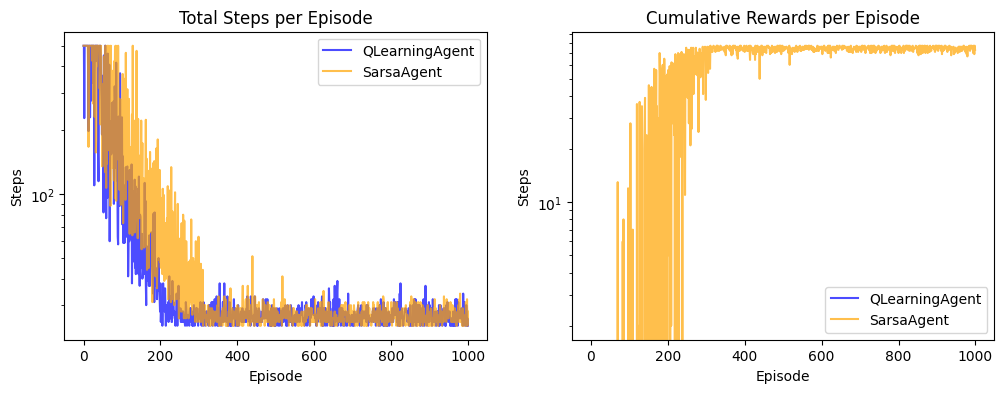

In [197]:
# your implements for comparisons
plot_comparison(
    steps_per_episode_QLearning, reward_per_episode_QLearning,
    steps_per_episode_Sarsa, reward_per_episode_Sarsa
)


Cette fonction permet de visualiser la politique apprise en extrayant, pour chaque état, l’action associée à la valeur Q maximale. La première carte thermique représente la valeur des états, tandis que la seconde montre la politique optimale sous forme de directions. Cela permet d’interpréter visuellement le comportement de l’agent dans l’environnement.

In [198]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_q_values_and_action_table(q_table, agent_name, grid_size=(10, 10)):
    action_arrow = {"left":'←', "right":'→', "up":'↑', "down":'↓', }

    # Assuming a 10x10 grid as per the initial code
    mat = np.zeros(grid_size) - np.inf
    directions = np.zeros(grid_size, dtype=str)

    # Process QLearning_table for visualization
    for ((x, y), action), value in q_table.items():
        if mat[(y, x)] < value:  # Assuming you want to display the max Q value for each position
            mat[y, x] = value  
            directions[y, x] = action_arrow[action] 

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(20, 7))
    mat[~np.isfinite(mat)] = 0
    vmin, vmax = np.min(mat), np.max(mat)
    # Q_values heatmap
    sns.heatmap(mat, annot=mat, fmt=".0f", cmap="vlag", ax=ax[0], annot_kws={"fontsize":12})
    ax[0].set_title(f"{agent_name} Q Values Table")
    ax[0].collections[0].set_clim(vmin,vmax)   

    # Action heatmap
    sns.heatmap(mat, annot=directions, fmt='', cmap="vlag", ax=ax[1], annot_kws={"fontsize":28})
    ax[1].set_title(f"{agent_name} Action Table")
    ax[1].collections[0].set_clim(vmin,vmax)   

    plt.show()


La carte des valeurs montre une augmentation progressive des Q-values à mesure que l’on se rapproche de l’objectif, ce qui indique que l’agent a correctement appris la qualité des états. Les positions proches du but ont des valeurs plus élevées, car elles permettent d’obtenir une récompense importante avec moins de pénalités.

La politique associée (flèches) oriente globalement l’agent vers l’objectif. Quelques incohérences apparaissent dans les zones éloignées, ce qui s’explique par une exploration encore présente et un nombre d’épisodes limité. Malgré cela, la stratégie reste cohérente.

L’apprentissage est incrémental : à chaque étape, la valeur est mise à jour selon
$
Q(s,a) \leftarrow Q(s,a) + \alpha \big(r + \gamma \max_a Q(s',a) - Q(s,a)\big)
$
ce qui permet d’ajuster progressivement les estimations.

Les valeurs élevées correspondent aux actions les plus avantageuses et font émerger implicitement un chemin optimal dans la grille.

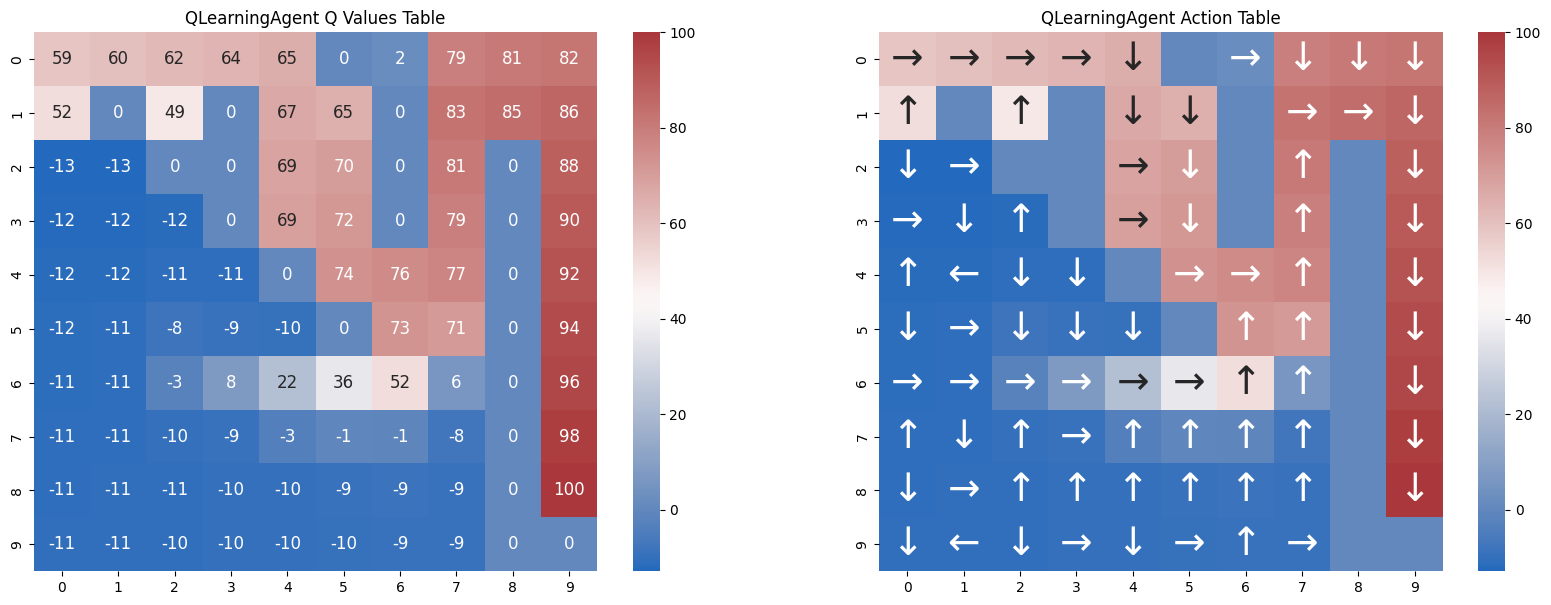

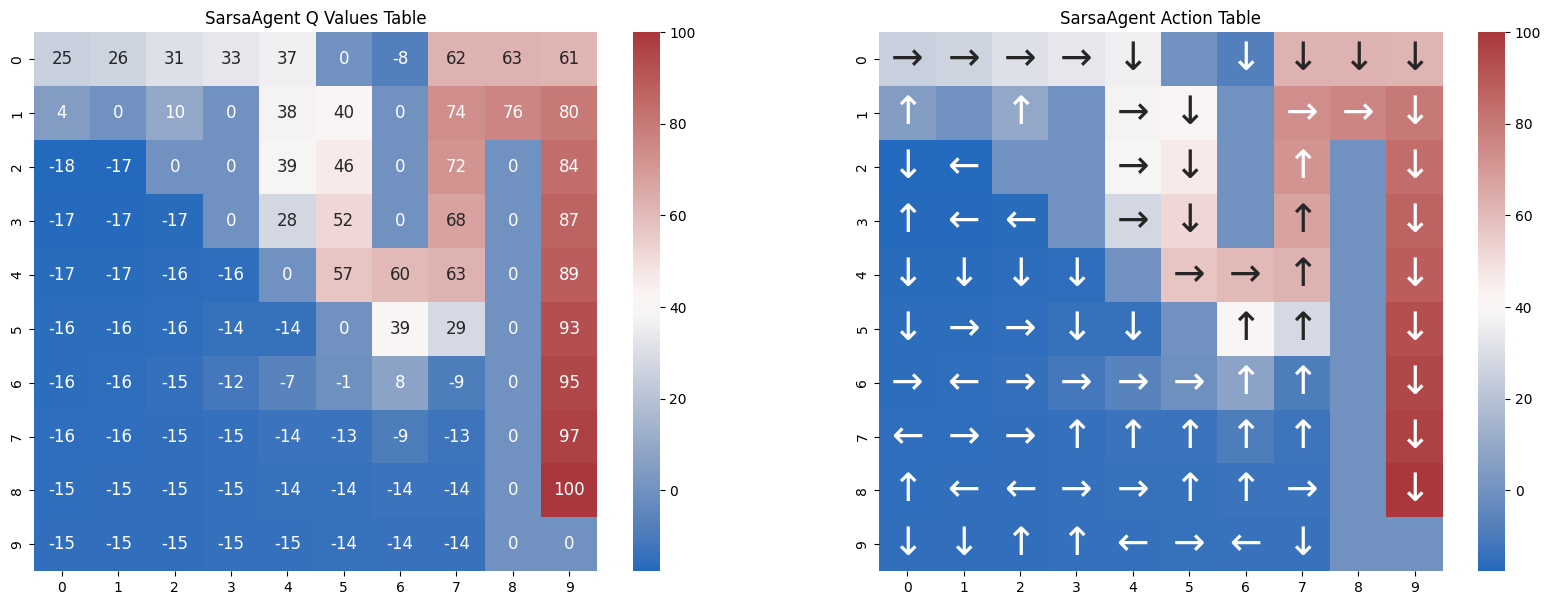

In [199]:
plot_q_values_and_action_table(q_learning_agent.q_table, 'QLearningAgent')
plot_q_values_and_action_table(sarsa_agent.q_table, 'SarsaAgent')


Pour avoir des temps d'exucution pas trop long, on baisse le nombre de steps et d'épisode, (cela forcément baissera les performances)

In [212]:
steps_per_episode_QLearning, reward_per_episode_QLearning, q_learning_agent = ExperimentAgent(QLearningAgent, num_episodes=1000 , max_steps=500)
steps_per_episode_Sarsa, reward_per_episode_Sarsa, sarsa_agent = ExperimentAgent(SarsaAgent, num_episodes=1000 , max_steps=500)

QLearningAgent entraîné pendant 1000 épisodes
SarsaAgent entraîné pendant 1000 épisodes


On voit bien qu'également baissé les steps et le nb d'épisode provoque une diminusion des pefs de la q table et sarsa agent table

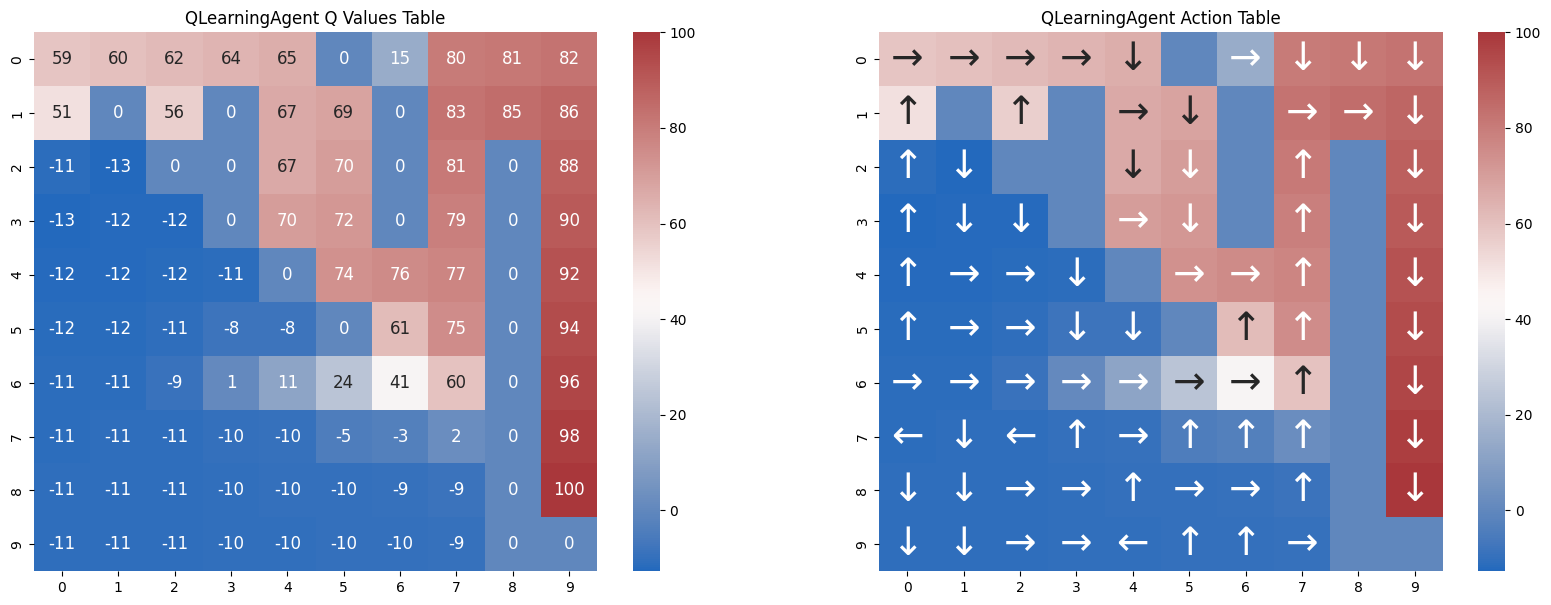

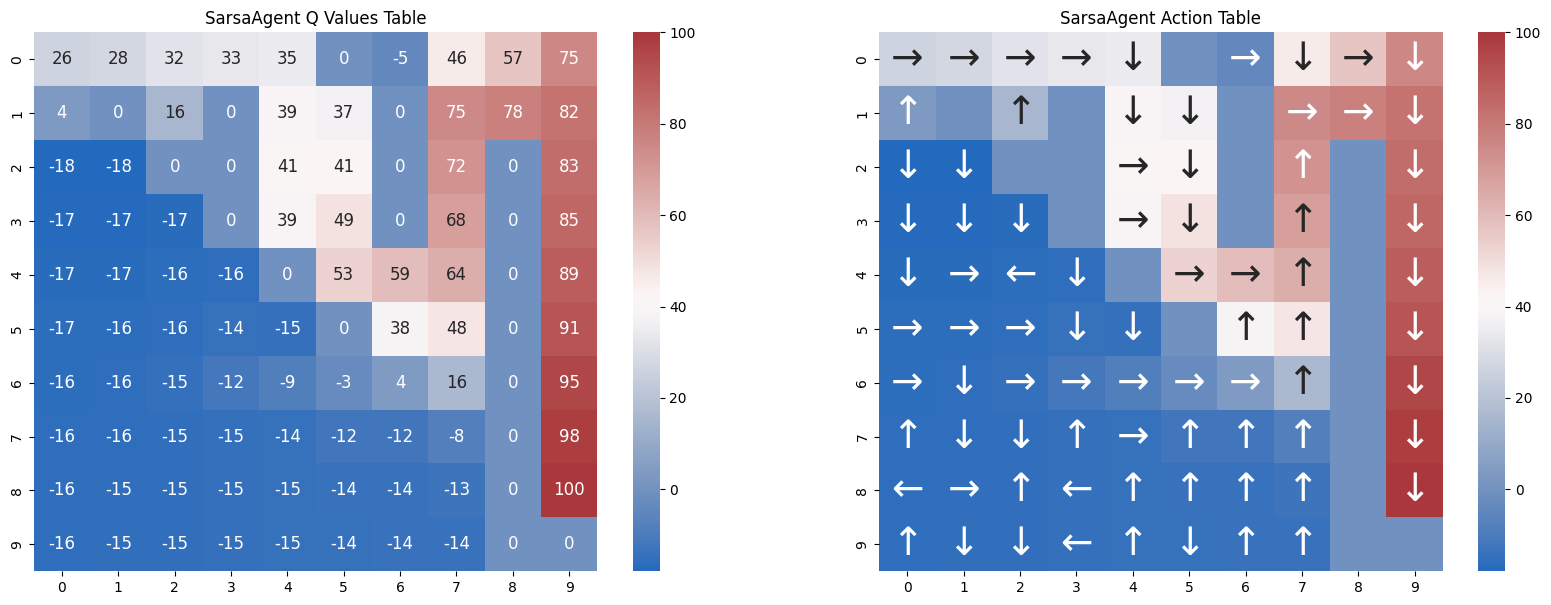

In [213]:
plot_q_values_and_action_table(q_learning_agent.q_table, 'QLearningAgent')
plot_q_values_and_action_table(sarsa_agent.q_table, 'SarsaAgent')


In [ ]:
from grid_world import SimulationGridWorld
a=SimulationGridWorld(QLearningAgent,
                    params={"gamma":0.99,
                            "epsilon":0.1, 
                            "alpha":0.1},
                    episode=100, 
                    grid_world=None,
                    auto_replay=True, 
                    ticks=50) # ticks is the frames per seconds

In [ ]:
print(steps_per_episode_QLearning)
print(reward_per_episode_QLearning)

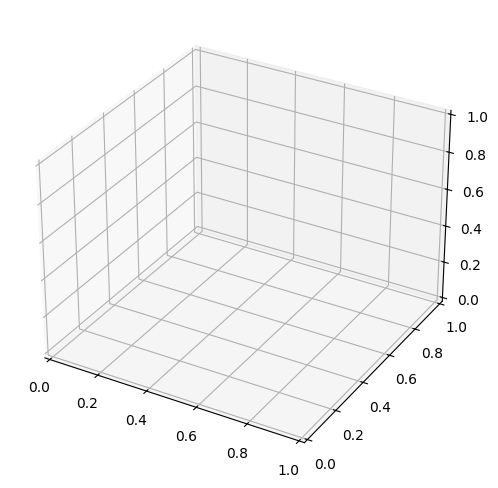

In [210]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from grid_world import GridWorld

# =========================
# Agent Q-Learning (simple)
# =========================
import random

class QLearningAgent:
    def __init__(self, grid_world, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.grid_world = grid_world
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = {}
        self.actions = ["up", "down", "left", "right"]

    def get_q(self, s, a):
        return self.q_table.get((s, a), 0)

    def choose_action(self, s):
        if random.random() < self.epsilon:
            return random.choice(self.actions)
        q_vals = [self.get_q(s, a) for a in self.actions]
        return self.actions[np.argmax(q_vals)]

    def learn(self, s, a, r, s2):
        q = self.get_q(s, a)
        max_q_next = max([self.get_q(s2, a2) for a2 in self.actions])
        new_q = q + self.alpha * (r + self.gamma * max_q_next - q)
        self.q_table[(s, a)] = new_q

# =========================
# Fonction V(s) robuste
# =========================
def compute_V(q_table):
    if len(q_table) == 0:
        return np.zeros((1,1))

    max_x = max([s[0][0] for s in q_table.keys()])
    max_y = max([s[0][1] for s in q_table.keys()])

    V = np.zeros((max_y+1, max_x+1))

    for ((x, y), a), v in q_table.items():
        if V[y, x] < v:
            V[y, x] = v

    return V

# =========================
# Entraînement + snapshots
# =========================
def train_with_snapshots(agent, grid_world, num_episodes=200, every=5, max_steps=200):
    Vs = []

    for ep in range(num_episodes):
        grid_world.player_position = grid_world.init_player_position
        steps = 0

        while not grid_world.is_game_over() and steps < max_steps:
            s = grid_world.player_position
            a = agent.choose_action(s)

            reached_goal = grid_world.move_player(a)
            s2 = grid_world.player_position

            r = 100 if reached_goal else -1

            agent.learn(s, a, r, s2)

            steps += 1

        if ep % every == 0:
            Vs.append(compute_V(agent.q_table))

    return Vs

# =========================
# Animation 3D
# =========================
def animate_V(V_list):
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')

    def update(i):
        ax.clear()
        V = V_list[i]

        H, W = V.shape
        X, Y = np.meshgrid(np.arange(W), np.arange(H))

        ax.plot_surface(X, Y, V, cmap='coolwarm')

        ax.set_title(f"Iteration {i}")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("V(s)")

    anim = FuncAnimation(fig, update, frames=len(V_list), interval=200)
    plt.show()
    return anim

# =========================
# MAIN
# =========================
grid_world = GridWorld(10, 10, goal_positions=[(9,9)])

agent = QLearningAgent(grid_world, alpha=0.1, gamma=0.99, epsilon=0.1)

Vs = train_with_snapshots(agent, grid_world, num_episodes=200, every=5)

anim = animate_V(Vs)

In [207]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_state_value_3D(q_table, grid_size=(10,10), title="State Value Plot"):
    
    # matrice des valeurs
    V = np.zeros(grid_size)

    # remplir avec max_a Q(s,a)
    for ((x, y), action), value in q_table.items():
        if V[y, x] < value:
            V[y, x] = value

    # coordonnées
    X = np.arange(0, grid_size[1])
    Y = np.arange(0, grid_size[0])
    X, Y = np.meshgrid(X, Y)

    # plot 3D
    fig = plt.figure(figsize=(10,7))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(X, Y, V, cmap='coolwarm')

    ax.set_title(title)
    ax.set_xlabel('X-coordinate')
    ax.set_ylabel('Y-coordinate')
    ax.set_zlabel('State Value')

    fig.colorbar(surf)
    plt.show()

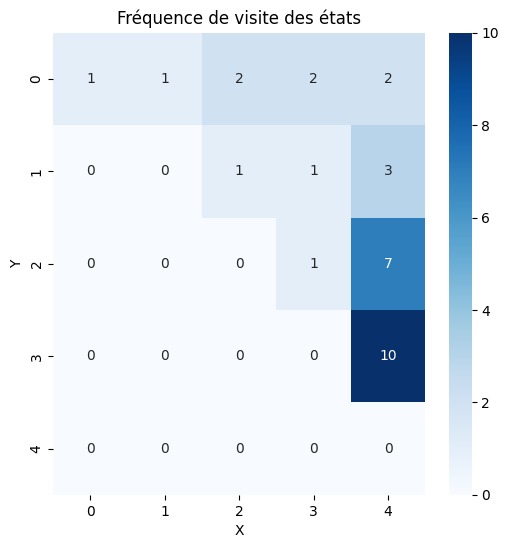

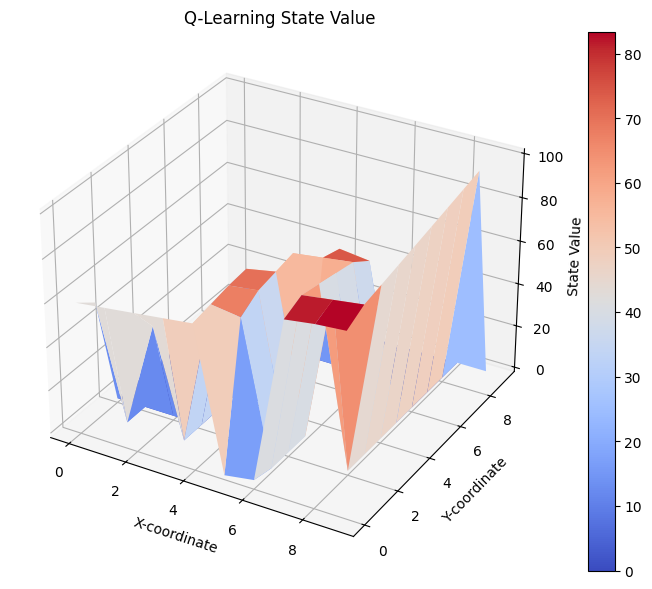

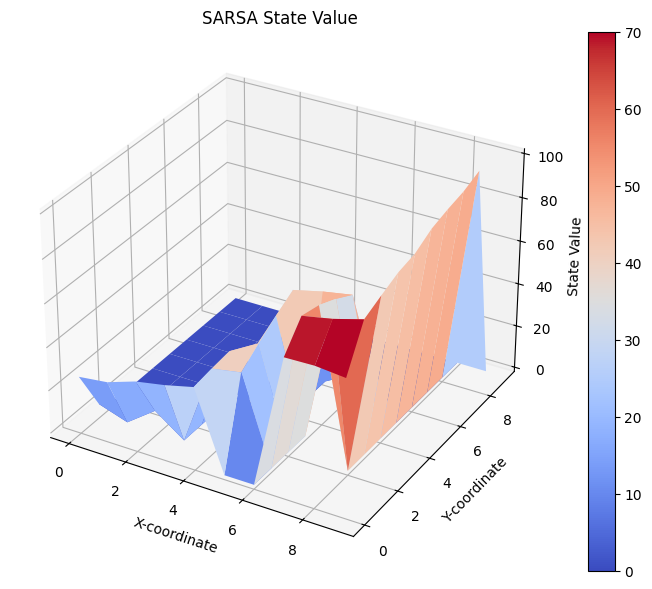

In [208]:
plot_trajectory_heatmap(q_learning_agent, grid_world)

plot_state_value_3D(q_learning_agent.q_table, title="Q-Learning State Value")
plot_state_value_3D(sarsa_agent.q_table, title="SARSA State Value")

In [185]:
from grid_world import SimulationGridWorld
SimulationGridWorld(SarsaAgent,
                    params={"gamma":0.99,
                            "epsilon":0.1, 
                            "alpha":0.1},
                    episode=5, 
                    grid_world=None,
                    auto_replay=True, 
                    ticks=50) # ticks is the frames per seconds

### Conclusion

Dans cette première partie, les résultats montrent que Q-Learning converge plus rapidement que SARSA grâce à son caractère off-policy, qui permet une propagation plus rapide des valeurs optimales. Cependant, cette approche repose sur une hypothèse optimiste du comportement futur, ce qui peut introduire une certaine instabilité.

À l’inverse, SARSA apprend de manière plus progressive en tenant compte des actions réellement exécutées, incluant l’exploration. Cela conduit à un comportement plus prudent et souvent plus stable, bien que plus lent à converger.

Ces différences illustrent l’impact du compromis exploration/exploitation sur l’apprentissage et mettent en évidence les avantages et limites de chaque approche dans un environnement simple comme GridWorld.


---

### Applications sur différentes cartes de Grid World (optionnel)
Dans cette deuxième partie du devoir Grid World, les blocs utilisés dans les configurations sont indiqués ci-dessous :
- Le bloc gris marque le point de départ du jeu.
- Les blocs verts (4) indiquent la destination à atteindre.
- Le bloc rouge représente le joueur.
- Les blocs blancs (0) représentent les routes praticables.
- Les blocs bleus (1) symbolisent les murs qui bloquent l'agent.
- Les blocs jaunes (2) indiquent les falaises qui ramènent l'agent au point de départ.
- Les blocs marron (3) représentent les marais qui donnent une récompense négative à l'agent.

**Tâches à faire** :
- Modifier alpha, gamma, epsilon, les récompenses, etc. afin de s'assurer que le nombre d'étapes par épisode des agents converge à la fin des expériences.
- Chercher, pour toutes les configurations, des paramètres avec lesquels l'agent Q-Learning et l'agent SARSA choisissent des chemins différents dans le Grid World.
- Discuter la solution finale, c'est-à-dire le chemin optimal obtenu dans les expériences.
- Discuter le nombre total d'étapes et les récompenses cumulées pour Q-Learning et SARSA.
- Discuter la table Q et la table d'actions pour Q-Learning et SARSA.

- Discuter les différents comportements des agents Q-Learning et SARSA à partir de vos expériences sur toutes les configurations.

**Remarque**
- Des fonctions d'exemple sont fournies pour lire une carte et ses paramètres depuis <<datas.json>>.
- La modification des récompenses, de gamma, de alpha, etc. doit être effectuée dans <<datas.json>>.



On dispose des cartes : map1, map2, map7, map8, map12, map16 : on va y entrainer pour chacune QlearningAgent et SarsaAgent :

Voici un exemple de chargement des données depuis le jeu de données JSON.

In [186]:
from grid_world import load_data
datas = load_data()
map_name = 'map_16'
key_list = datas[map_name].keys()
print("key_list:", key_list)

map = datas[map_name]["map"]
print('\nmap_name:', map_name)
for line in map:
    print(line)

print("params_list:", datas[map_name]["parameters"])

loaded maps : dict_keys(['map_1', 'map_2', 'map_7', 'map_8', 'map_12', 'map_16'])
key_list: dict_keys(['map', 'start_place_x', 'start_place_y', 'parameters'])

map_name: map_16
[0, 0, 2, 2, 2, 2, 2, 2, 0, 4]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
params_list: {'alpha': 0.05, 'gamma': 0.99, 'epsilon': 0.9, 'episodes': 1000, 'epsilon_min': 0.01, 'epsilon_decay_rate': 0.01, 'reward_final': 1000, 'reward_marsh': -10, 'step_limit': 1000, 'reward_default': -1}


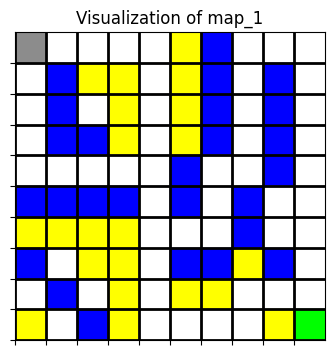

In [187]:
from grid_world import *
plot_grid_world(datas, "map_1")

In [191]:
from grid_world import GridWorld, PygameGridWorld

# check your taskbar for running pygame application GridWorld
game = PygameGridWorld()
game.main(auto_close=True, map_name="map_1", datas=datas) # auto_close will close screen automtatically at the end of game.

### Expériences

In [ ]:
fiat un code dans lequel tu load lamap 1 et tu fais jouer un agent qlearning dessus et tu affiche la map a la fin avec les trajectoires de l'agent et la valeur de chaque état en 3D 
pour les hyperparametres on a le choix entre "start_place_x": 0, "start_place_y": 0, "parameters": {"alpha": 0.05, "gamma": 0.99, "epsilon": 0.9, "episodes": 1000, "epsilon_min": 0.01, "epsilon_decay_rate": 0.01, "reward_final": 1000, "reward_marsh": -10,"step_limit":1000, "reward_default": -1}}, 
donc faut utiliser get_reward et toutes les fonctions associés.  on fait ensuite un grid search α ∈ {0.05, 0.1, 0.5}
γ ∈ {0.9, 0.99}
ε initial ∈ {0.9, 0.5} on y entraine q learning et sarsa et on reprends la moyenne de steps le erward moyen et la variance pour comparer donc on tra pour les 12 models sur le meme plt les 3 edan un pmlotdif on fait 2 cas ensuite un avec falaise -100 marais -10 pour montrer risque vs non risque


on fix : num_episodes = 300
max_steps = 200

# Grid Search Q-Learning & SARSA sur Map 1

Ce bloc ajoute l'entraînement et la comparaison Q-Learning/SARSA sur la map 1, avec grid search sur les hyperparamètres, affichage des trajectoires et valeurs d'états, et comparaison des performances pour deux cas de récompenses (falaise -100 ou -10).

In [ ]:
# Added by Codex - visible code cells
import itertools
import random

import matplotlib.pyplot as plt
import numpy as np
import pickle
from matplotlib.colors import BoundaryNorm, ListedColormap
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from grid_world import GridWorld, load_data


SEED = 42
random.seed(SEED)
np.random.seed(SEED)

MAP_NAME = "map_1"
NUM_EPISODES = 300
MAX_STEPS = 200


class QLearningAgent:
    def __init__(self, grid_world, alpha=0.1, gamma=0.95, epsilon=0.1):
        self.grid_world = grid_world
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = {}
        self.actions = ["up", "down", "left", "right"]

    def get_q_value(self, state, action):
        return self.q_table.get((state, action), 0)

    def update_q_value(self, state, action, new_value):
        self.q_table[(state, action)] = new_value

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.choice(self.actions)
        q_values = [self.get_q_value(state, action) for action in self.actions]
        return self.actions[int(np.argmax(q_values))]

    def learn(self, state, action, reward, next_state):
        current_q_value = self.get_q_value(state, action)
        next_q_values = [self.get_q_value(next_state, next_action) for next_action in self.actions]
        max_next_q_value = max(next_q_values)
        new_q_value = current_q_value + self.alpha * (
            reward + self.gamma * max_next_q_value - current_q_value
        )
        self.update_q_value(state, action, new_q_value)


class SarsaAgent:
    def __init__(self, grid_world, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.grid_world = grid_world
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = {}
        self.actions = ["up", "down", "left", "right"]

    def get_q_value(self, state, action):
        return self.q_table.get((state, action), 0)

    def update_q_value(self, state, action, new_value):
        self.q_table[(state, action)] = new_value

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.choice(self.actions)
        q_values = [self.get_q_value(state, action) for action in self.actions]
        return self.actions[int(np.argmax(q_values))]

    def learn(self, state, action, reward, next_state, next_action):
        current_q_value = self.get_q_value(state, action)
        next_q_value = self.get_q_value(next_state, next_action)
        new_q_value = current_q_value + self.alpha * (
            reward + self.gamma * next_q_value - current_q_value
        )
        self.update_q_value(state, action, new_q_value)


In [ ]:
def make_grid_world_from_datas(datas, map_name):
    grid = np.array(datas[map_name]["map"])
    wall_positions = []
    cliff_positions = []
    marsh_positions = []
    goal_positions = []

    for y in range(grid.shape[0]):
        for x in range(grid.shape[1]):
            cell = grid[y, x]
            if cell == 1:
                wall_positions.append((x, y))
            elif cell == 2:
                cliff_positions.append((x, y))
            elif cell == 3:
                marsh_positions.append((x, y))
            elif cell == 4:
                goal_positions.append((x, y))

    start = (datas[map_name]["start_place_x"], datas[map_name]["start_place_y"])
    return GridWorld(
        width=grid.shape[1],
        height=grid.shape[0],
        player_position=start,
        wall_positions=wall_positions,
        goal_positions=goal_positions,
        cliff_positions=cliff_positions,
        marsh_positions=marsh_positions,
    )


def get_intended_position(state, action, grid_world):
    x, y = state
    if action == "up":
        y = max(0, y - 1)
    elif action == "down":
        y = min(grid_world.height - 1, y + 1)
    elif action == "left":
        x = max(0, x - 1)
    elif action == "right":
        x = min(grid_world.width - 1, x + 1)
    return (x, y)


def get_reward(
    grid_world,
    reached_goal,
    intended_position,
    reward_final=1000,
    reward_goal=None,
    reward_default=-1,
    reward_marsh=-10,
    reward_cliff=-100,
):
    if reward_goal is not None:
        reward_final = reward_goal
    if reached_goal:
        return reward_final
    if intended_position in grid_world.cliff_positions:
        return reward_cliff
    if intended_position in grid_world.marsh_positions:
        return reward_marsh
    return reward_default


def train_one_episode(agent, grid_world, max_steps=200, rewards_config=None):
    rewards_config = rewards_config or {}
    steps = 0
    total_reward = 0
    trajectory = [grid_world.player_position]

    if agent.__class__.__name__ == "SarsaAgent":
        state = grid_world.player_position
        action = agent.choose_action(state)

        while not grid_world.is_game_over() and steps < max_steps:
            intended_position = get_intended_position(state, action, grid_world)
            reached_goal = grid_world.move_player(action)
            next_state = grid_world.player_position
            reward = get_reward(
                grid_world, reached_goal, intended_position, **rewards_config
            )
            next_action = agent.choose_action(next_state)

            agent.learn(state, action, reward, next_state, next_action)
            state, action = next_state, next_action
            steps += 1
            total_reward += reward
            trajectory.append(next_state)
    else:
        while not grid_world.is_game_over() and steps < max_steps:
            state = grid_world.player_position
            action = agent.choose_action(state)
            intended_position = get_intended_position(state, action, grid_world)
            reached_goal = grid_world.move_player(action)
            next_state = grid_world.player_position
            reward = get_reward(
                grid_world, reached_goal, intended_position, **rewards_config
            )

            agent.learn(state, action, reward, next_state)
            steps += 1
            total_reward += reward
            trajectory.append(next_state)

    return steps, total_reward, trajectory


In [ ]:
def train_agent_on_map(
    agent_class,
    datas,
    map_name,
    alpha,
    gamma,
    epsilon,
    num_episodes=300,
    max_steps=200,
    epsilon_min=0.01,
    epsilon_decay_rate=0.01,
    rewards_config=None,
):
    grid_world = make_grid_world_from_datas(datas, map_name)
    agent = agent_class(grid_world, alpha=alpha, gamma=gamma, epsilon=epsilon)
    steps_per_episode = []
    rewards_per_episode = []

    for _ in range(num_episodes):
        grid_world.player_position = grid_world.init_player_position
        steps, total_reward, _trajectory = train_one_episode(
            agent, grid_world, max_steps, rewards_config
        )
        steps_per_episode.append(steps)
        rewards_per_episode.append(total_reward)
        agent.epsilon = max(epsilon_min, agent.epsilon * np.exp(-epsilon_decay_rate))

    return {
        "agent": agent,
        "grid_world": grid_world,
        "steps": np.array(steps_per_episode),
        "rewards": np.array(rewards_per_episode),
    }


def greedy_trajectory(agent, grid_world, max_steps=200):
    old_epsilon = agent.epsilon
    agent.epsilon = 0.0
    grid_world.player_position = grid_world.init_player_position
    trajectory = [grid_world.player_position]

    for _ in range(max_steps):
        if grid_world.is_game_over():
            break
        state = grid_world.player_position
        action = agent.choose_action(state)
        grid_world.move_player(action)
        trajectory.append(grid_world.player_position)

    agent.epsilon = old_epsilon
    return trajectory


def run_grid_search(datas, map_name, reward_scenarios, q_learning_cls, sarsa_cls):
    alphas = [0.05, 0.1, 0.5]
    gammas = [0.9, 0.99]
    epsilons = [0.9, 0.5]
    results = []

    base_params = datas[map_name]["parameters"].copy()
    base_params.update({"episodes": NUM_EPISODES, "step_limit": MAX_STEPS})

    config_id = 0
    for alpha, gamma, epsilon in itertools.product(alphas, gammas, epsilons):
        config_id += 1
        for scenario_name, scenario_rewards in reward_scenarios.items():
            rewards_config = {
                "reward_final": base_params.get("reward_final", 1000),
                "reward_default": base_params.get("reward_default", -1),
                "reward_marsh": scenario_rewards["reward_marsh"],
                "reward_cliff": scenario_rewards["reward_cliff"],
            }
            for agent_class in [q_learning_cls, sarsa_cls]:
                run = train_agent_on_map(
                    agent_class,
                    datas,
                    map_name,
                    alpha=alpha,
                    gamma=gamma,
                    epsilon=epsilon,
                    num_episodes=NUM_EPISODES,
                    max_steps=MAX_STEPS,
                    epsilon_min=base_params.get("epsilon_min", 0.01),
                    epsilon_decay_rate=base_params.get("epsilon_decay_rate", 0.01),
                    rewards_config=rewards_config,
                )
                results.append(
                    {
                        "config_id": config_id,
                        "scenario": scenario_name,
                        "agent_name": agent_class.__name__,
                        "alpha": alpha,
                        "gamma": gamma,
                        "epsilon_initial": epsilon,
                        "mean_steps": float(np.mean(run["steps"])),
                        "mean_reward": float(np.mean(run["rewards"])),
                        "var_steps": float(np.var(run["steps"])),
                        "var_reward": float(np.var(run["rewards"])),
                        "run": run,
                    }
                )
    return results


In [ ]:
def plot_grid_search_results(results, scenario_name, map_name):
    rows = [r for r in results if r["scenario"] == scenario_name]
    configs = sorted({r["config_id"] for r in rows})
    labels = [f"C{c}" for c in configs]
    metrics = [
        ("mean_steps", "Steps moyens"),
        ("mean_reward", "Reward moyen"),
        ("var_reward", "Variance reward"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
    for ax, (metric, title) in zip(axes, metrics):
        for agent_name, color in [
            ("QLearningAgent", "#2563eb"),
            ("SarsaAgent", "#dc2626"),
        ]:
            values = [
                next(
                    r[metric]
                    for r in rows
                    if r["config_id"] == c and r["agent_name"] == agent_name
                )
                for c in configs
            ]
            ax.plot(labels, values, marker="o", linewidth=2, label=agent_name, color=color)
        ax.set_title(title)
        ax.set_xlabel("Configuration")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Valeur")
    axes[-1].legend()
    fig.suptitle(f"Grid search sur {map_name} - {scenario_name}")
    plt.tight_layout()
    plt.show()

    print("Correspondance des configurations :")
    for c in configs:
        row = next(r for r in rows if r["config_id"] == c)
        print(
            f"C{c}: alpha={row['alpha']}, gamma={row['gamma']}, "
            f"epsilon={row['epsilon_initial']}"
        )


def state_values(agent, grid_world):
    values = np.zeros((grid_world.height, grid_world.width), dtype=float)
    for y in range(grid_world.height):
        for x in range(grid_world.width):
            state = (x, y)
            if state in grid_world.wall_positions:
                values[y, x] = np.nan
            else:
                values[y, x] = max(agent.get_q_value(state, a) for a in agent.actions)
    return values


def plot_trajectory_and_values_3d(agent, grid_world, trajectory, title):
    grid = np.zeros((grid_world.height, grid_world.width), dtype=int)
    for x, y in grid_world.wall_positions:
        grid[y, x] = 1
    for x, y in grid_world.cliff_positions:
        grid[y, x] = 2
    for x, y in grid_world.marsh_positions:
        grid[y, x] = 3
    for x, y in grid_world.goal_positions:
        grid[y, x] = 4

    sx, sy = grid_world.init_player_position
    display_grid = grid.copy()
    display_grid[sy, sx] = 5

    colors = ["#f8fafc", "#2563eb", "#facc15", "#92400e", "#22c55e", "#9ca3af"]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5], cmap.N)
    values = state_values(agent, grid_world)

    fig = plt.figure(figsize=(17, 7))
    ax_map = fig.add_subplot(1, 2, 1)
    ax_3d = fig.add_subplot(1, 2, 2, projection="3d")

    ax_map.imshow(display_grid, cmap=cmap, norm=norm)
    ax_map.set_xticks(np.arange(grid_world.width))
    ax_map.set_yticks(np.arange(grid_world.height))
    ax_map.set_xticks(np.arange(-0.5, grid_world.width, 1), minor=True)
    ax_map.set_yticks(np.arange(-0.5, grid_world.height, 1), minor=True)
    ax_map.grid(which="minor", color="#111827", linewidth=1.0)
    ax_map.tick_params(which="minor", bottom=False, left=False)
    ax_map.set_title(f"Trajectoire finale - {title}")

    if trajectory:
        xs = [pos[0] for pos in trajectory]
        ys = [pos[1] for pos in trajectory]
        ax_map.plot(xs, ys, color="#ef4444", linewidth=2.5, marker="o", markersize=4)

    ax_map.text(sx, sy, "S", ha="center", va="center", fontweight="bold")
    for gx, gy in grid_world.goal_positions:
        ax_map.text(gx, gy, "G", ha="center", va="center", fontweight="bold")

    xs = []
    ys = []
    zs = []
    dx = []
    dy = []
    dz = []
    bar_colors = []

    for y in range(grid_world.height):
        for x in range(grid_world.width):
            if (x, y) in grid_world.wall_positions or np.isnan(values[y, x]):
                continue
            xs.append(x - 0.4)
            ys.append(y - 0.4)
            zs.append(0)
            dx.append(0.8)
            dy.append(0.8)
            dz.append(values[y, x])
            bar_colors.append(colors[grid[y, x]] if grid[y, x] < len(colors) else colors[0])

    ax_3d.bar3d(xs, ys, zs, dx, dy, dz, shade=True, color=bar_colors, alpha=0.9)
    ax_3d.set_title(f"Valeur V(s)=max_a Q(s,a) - {title}")
    ax_3d.set_xlabel("x")
    ax_3d.set_ylabel("y")
    ax_3d.set_zlabel("V(s)")
    ax_3d.view_init(elev=30, azim=-55)

    plt.tight_layout()
    plt.show()


In [ ]:
def run_experiment(q_learning_cls, sarsa_cls):
    datas = load_data()
    reward_scenarios = {
        "penalite moderee": {"reward_cliff": -10, "reward_marsh": -10},
        "risque fort": {"reward_cliff": -100, "reward_marsh": -10},
    }

    results = run_grid_search(
        datas,
        MAP_NAME,
        reward_scenarios,
        q_learning_cls=q_learning_cls,
        sarsa_cls=sarsa_cls,
    )

    plot_grid_search_results(results, "penalite moderee", MAP_NAME)
    plot_grid_search_results(results, "risque fort", MAP_NAME)

    best_q_risk = max(
        [
            r
            for r in results
            if r["scenario"] == "risque fort" and r["agent_name"] == "QLearningAgent"
        ],
        key=lambda r: r["mean_reward"],
    )

    best_run = best_q_risk["run"]
    final_trajectory = greedy_trajectory(
        best_run["agent"], best_run["grid_world"], max_steps=MAX_STEPS
    )
    plot_trajectory_and_values_3d(
        best_run["agent"],
        best_run["grid_world"],
        final_trajectory,
        title=f"Q-Learning C{best_q_risk['config_id']} risque fort",
    )

    print(
        "Meilleure config Q-Learning risque fort:",
        {
            "config_id": best_q_risk["config_id"],
            "alpha": best_q_risk["alpha"],
            "gamma": best_q_risk["gamma"],
            "epsilon_initial": best_q_risk["epsilon_initial"],
            "mean_steps": round(best_q_risk["mean_steps"], 2),
            "mean_reward": round(best_q_risk["mean_reward"], 2),
            "var_reward": round(best_q_risk["var_reward"], 2),
        },
    )

run_experiment(QLearningAgent, SarsaAgent)


In [ ]:
# Added by Codex - multi-map launcher
from map1_qlearning_sarsa_gridsearch import FULL_GRID, LIGHT_GRID, print_report_ready_summary, run_map_pipeline, run_selected_maps

# 1) Une map cle avec plots complets
# results_map16, best_map16 = run_map_pipeline(QLearningAgent, SarsaAgent, map_name="map_16", grid_config=FULL_GRID, show_plots=True, show_3d=True)

# 2) Toutes les maps avec la meme pipeline, sans les graphiques pour aller plus vite
all_results, all_best_rows = run_selected_maps(
    QLearningAgent,
    SarsaAgent,
    map_names=["map_1", "map_2", "map_7", "map_8", "map_12", "map_16"],
    grid_config=LIGHT_GRID,
    show_plots=False,
)

print_report_ready_summary(all_best_rows)
